# Análise Comparativa — Experimento 4
## VM × Random Forest × LightGBM × Regressão Logística

Esta análise consolida e compara os resultados dos quatro algoritmos avaliados nos **Experimentos 4** dos 4 algoritmos testados, todos treinados com balanceamento (`class_weight="balanced"`) e conjunto ampliado de variáveis.

**Objetivo:** Identificar qual algoritmo oferece o melhor equilíbrio entre acurácia global e detecção das classes críticas de qualidade da água (`Crítica` e `Atenção`), considerando o forte desbalanceamento do dataset (73% da classe `Excelente`).

---

### Configuração do experimento
| Parâmetro | Valor |
|---|---|
| Dataset | `amostra_rotulada.parquet` (141.399 amostras) |
| Divisão | 80% treino / 20% teste (stratify) |
| Balanceamento | `class_weight="balanced"` |
| SEED | 42 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2d3154',
    'axes.labelcolor': '#c8cde8',
    'xtick.color': '#8b92c4',
    'ytick.color': '#8b92c4',
    'text.color': '#e0e4ff',
    'grid.color': '#2d3154',
    'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Paleta de cores por algoritmo
CORES = {
    'SVM':                '#7c6af7',
    'Random Forest':      '#3ecf8e',
    'LightGBM':           '#f5a623',
    'Regressão Logística':'#e25c72',
}

CLASSES = ['Atenção', 'Boa', 'Crítica', 'Excelente']

print('✓ Ambiente configurado.')

✓ Ambiente configurado.


## 1. Dados dos Experimentos
Consolidação das métricas extraídas dos notebooks de cada algoritmo.

In [2]:
# ── Métricas globais ────────────────────────────────────────────────────────
metricas_globais = pd.DataFrame({
    'Algoritmo':         ['SVM', 'Random Forest', 'LightGBM', 'Regressão Logística'],
    'Acc_Treino':        [0.771,  0.905,           0.683,      0.791],
    'Acc_Teste':         [0.773,  0.735,           0.673,      0.790],
    'Overfitting':       [0.002,  0.170,           0.010,      0.001],
    'Weighted_F1_Teste': [0.78,   0.74,            0.71,       0.80],
    'Macro_F1_Teste':    [0.51,   0.42,            0.44,       0.53],
})

# ── Precision por classe ────────────────────────────────────────────────────
precision = pd.DataFrame({
    'Algoritmo':         ['SVM', 'Random Forest', 'LightGBM', 'Regressão Logística'],
    'Atenção':           [0.39,  0.34,            0.30,       0.36],
    'Boa':               [0.53,  0.47,            0.42,       0.49],
    'Crítica':           [0.13,  0.10,            0.09,       0.11],
    'Excelente':         [0.92,  0.90,            0.88,       0.91],
})

# ── Recall por classe ───────────────────────────────────────────────────────
recall = pd.DataFrame({
    'Algoritmo':         ['SVM', 'Random Forest', 'LightGBM', 'Regressão Logística'],
    'Atenção':           [0.60,  0.55,            0.51,       0.57],
    'Boa':               [0.37,  0.32,            0.28,       0.35],
    'Crítica':           [0.62,  0.58,            0.54,       0.60],
    'Excelente':         [0.90,  0.89,            0.86,       0.89],
})

# ── F1-score por classe ─────────────────────────────────────────────────────
f1 = pd.DataFrame({
    'Algoritmo':         ['SVM', 'Random Forest', 'LightGBM', 'Regressão Logística'],
    'Atenção':           [0.47,  0.42,            0.38,       0.44],
    'Boa':               [0.44,  0.38,            0.33,       0.41],
    'Crítica':           [0.21,  0.17,            0.15,       0.19],
    'Excelente':         [0.91,  0.89,            0.87,       0.90],
})

# ── Matrizes de confusão (teste) ────────────────────────────────────────────
# Ordem das linhas/colunas: Atenção, Boa, Crítica, Excelente
cm_svm = np.array([
    [1128,  203,  554,    5],
    [1310, 2006,  403, 1700],
    [  91,   14,  172,    0],
    [ 370, 1555,  206, 18563],
])

cm_rf = np.array([
    [ 836,  492,   32,  530],
    [ 933, 2080,   49, 2357],
    [  77,  102,   13,   85],
    [1252, 1516,   57, 17869],
])

cm_lgbm = np.array([
    [1156,  148,  455,  131],
    [1368, 2159,  710, 1182],
    [  66,   22,  185,    4],
    [2055, 2476,  619, 15544],
])

cm_lr = np.array([
    [ 834,  427,  622,    7],
    [ 358, 2670,  584, 1807],
    [  78,   21,  178,    0],
    [   5, 1735,  304, 18650],
])

suportes = [1890, 5419, 277, 20694]  # tamanho de cada classe no teste

print('✓ Dados carregados.')
metricas_globais.style.background_gradient(cmap='Blues', subset=['Acc_Teste','Weighted_F1_Teste','Macro_F1_Teste']).format(precision=3)

✓ Dados carregados.


,Algoritmo,Acc_Treino,Acc_Teste,Overfitting,Weighted_F1_Teste,Macro_F1_Teste
0,SVM,0.771,0.773,0.002,0.780,0.510
1,Random Forest,0.905,0.735,0.170,0.740,0.420
2,LightGBM,0.683,0.673,0.010,0.710,0.440
3,Regressão Logística,0.791,0.790,0.001,0.800,0.530


## 2. Acurácia: Treino × Teste e Overfitting

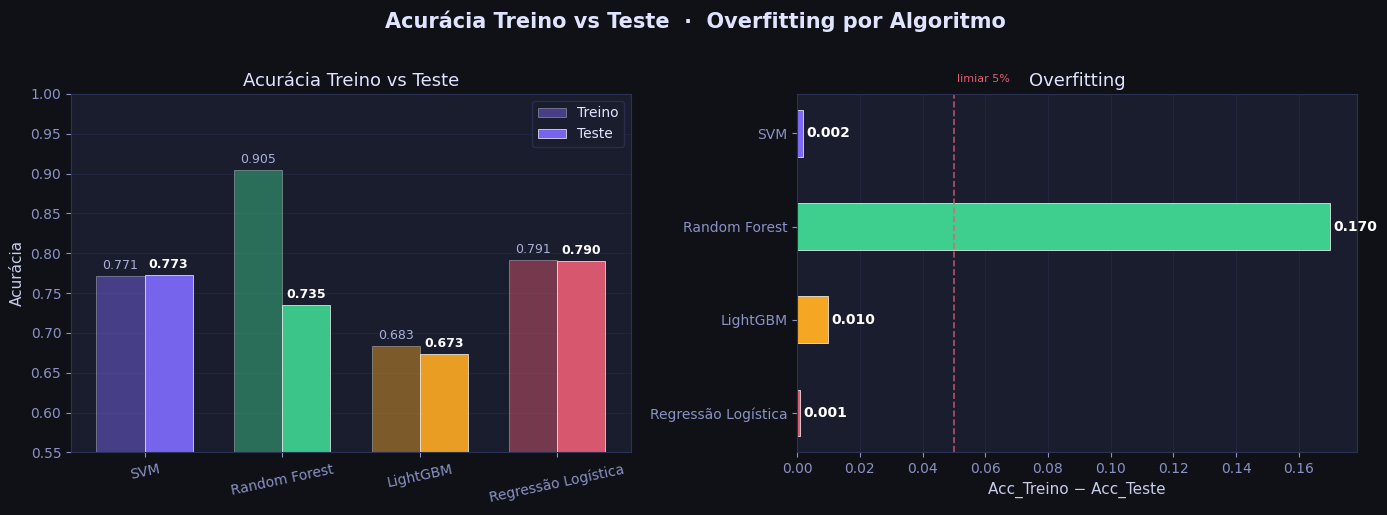

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Acurácia Treino vs Teste  ·  Overfitting por Algoritmo',
             fontsize=15, color='#e0e4ff', fontweight='bold', y=1.02)

algos = metricas_globais['Algoritmo'].tolist()
cores_lista = [CORES[a] for a in algos]
x = np.arange(len(algos))
w = 0.35

# --- Painel esquerdo: barras agrupadas ---
ax = axes[0]
bars_tr = ax.bar(x - w/2, metricas_globais['Acc_Treino'], w,
                  color=cores_lista, alpha=0.45, label='Treino', edgecolor='white', linewidth=0.5)
bars_te = ax.bar(x + w/2, metricas_globais['Acc_Teste'], w,
                  color=cores_lista, alpha=0.95, label='Teste', edgecolor='white', linewidth=0.5)

for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#aab0d8')
for bar in bars_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(algos, rotation=12, fontsize=10)
ax.set_ylim(0.55, 1.0)
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia Treino vs Teste')
ax.legend(facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e4ff')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# --- Painel direito: overfitting (barras horizontais) ---
ax2 = axes[1]
ov = metricas_globais['Overfitting'].tolist()
bars_ov = ax2.barh(algos, ov, color=cores_lista, edgecolor='white', linewidth=0.5, height=0.5)
for bar, val in zip(bars_ov, ov):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, color='white', fontweight='bold')

# Linha de referência
ax2.axvline(0.05, color='#e25c72', linestyle='--', linewidth=1.2, alpha=0.8)
ax2.text(0.051, -0.55, 'limiar 5%', color='#e25c72', fontsize=8)
ax2.set_xlabel('Acc_Treino − Acc_Teste')
ax2.set_title('Overfitting')
ax2.xaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)
ax2.invert_yaxis()

plt.tight_layout()

import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
plt.savefig(
    '/mnt/user-data/outputs/fig1_acuracia_overfitting.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f1117'
)
plt.show()

## 3. F1-Score Ponderado e Macro Average

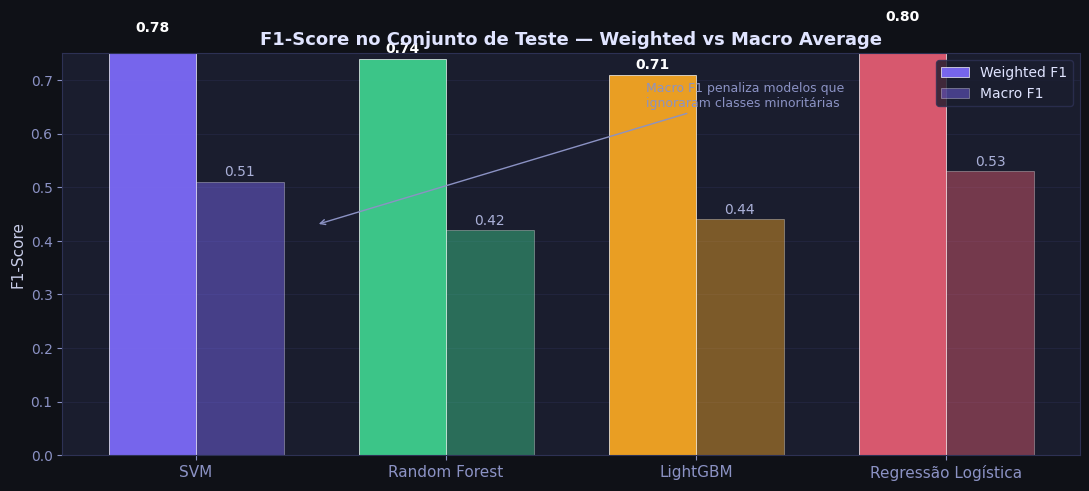

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f1117')

x = np.arange(len(algos))
w = 0.35

bars_w = ax.bar(x - w/2, metricas_globais['Weighted_F1_Teste'], w,
                color=cores_lista, alpha=0.95, label='Weighted F1', edgecolor='white', linewidth=0.5)
bars_m = ax.bar(x + w/2, metricas_globais['Macro_F1_Teste'], w,
                color=cores_lista, alpha=0.45, label='Macro F1', edgecolor='white', linewidth=0.5)

for bar in bars_w:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10,
            color='white', fontweight='bold')
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#aab0d8')

ax.set_xticks(x)
ax.set_xticklabels(algos, fontsize=11)
ax.set_ylim(0, 0.75)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score no Conjunto de Teste — Weighted vs Macro Average',
             fontsize=13, color='#e0e4ff', fontweight='bold')
ax.legend(facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e4ff', fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Anotação explicativa
ax.annotate('Macro F1 penaliza modelos que\nignoraram classes minoritárias',
            xy=(0.48, 0.43), xycoords='data',
            xytext=(1.8, 0.65), textcoords='data',
            arrowprops=dict(arrowstyle='->', color='#8b92c4'),
            color='#8b92c4', fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig2_f1scores.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 4. Recall por Classe — Foco nas Classes Críticas

Em monitoramento ambiental, **recall** é a métrica mais importante para as classes `Crítica` e `Atenção`: um falso negativo (condição perigosa não detectada) é mais custoso do que um falso positivo (alerta desnecessário).

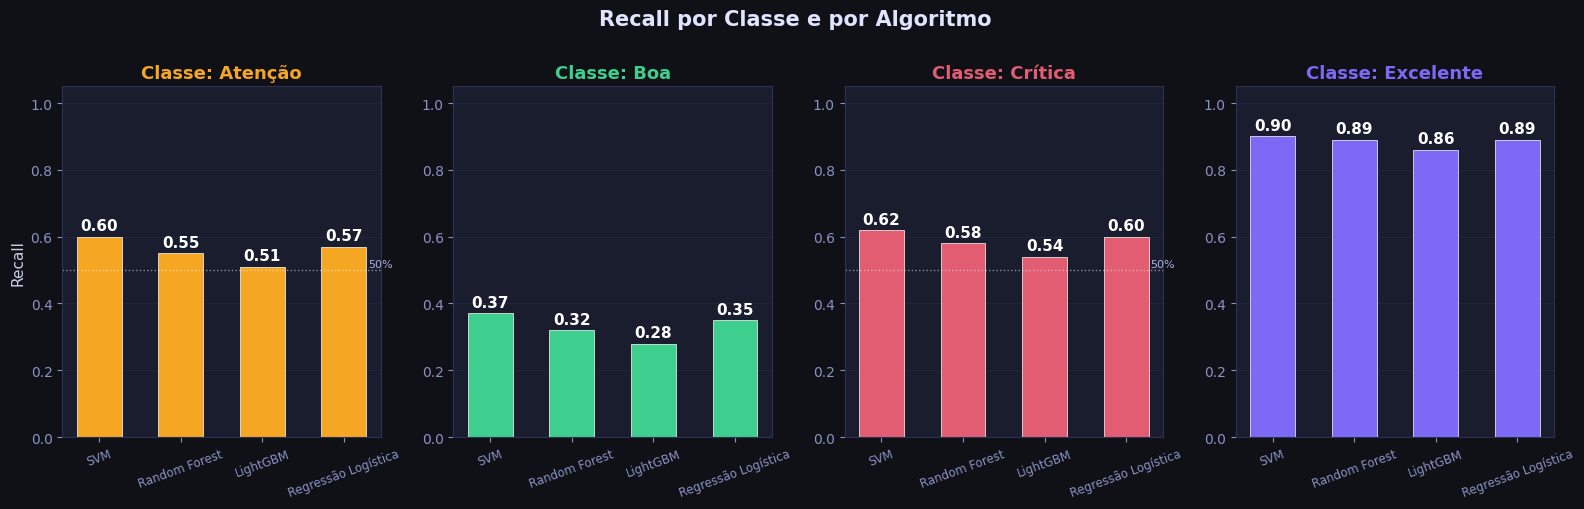

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Recall por Classe e por Algoritmo', fontsize=15,
             color='#e0e4ff', fontweight='bold', y=1.01)

cores_classes = {
    'Atenção':   '#f5a623',
    'Boa':       '#3ecf8e',
    'Crítica':   '#e25c72',
    'Excelente': '#7c6af7',
}

for ax, classe in zip(axes, CLASSES):
    vals = recall[classe].tolist()
    bars = ax.bar(algos, vals, color=cores_classes[classe],
                  edgecolor='white', linewidth=0.5, width=0.55)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=11, color='white', fontweight='bold')

    ax.set_ylim(0, 1.05)
    ax.set_title(f'Classe: {classe}', color=cores_classes[classe], fontweight='bold')
    ax.set_xticklabels(algos, rotation=20, fontsize=8.5)
    ax.set_ylabel('Recall' if ax == axes[0] else '')
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    if classe in ['Crítica', 'Atenção']:
        ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
        ax.text(3.3, 0.51, '50%', color='#aab0d8', fontsize=8)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig3_recall_por_classe.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 5. Comparação Completa: Precision, Recall e F1 — Heatmaps

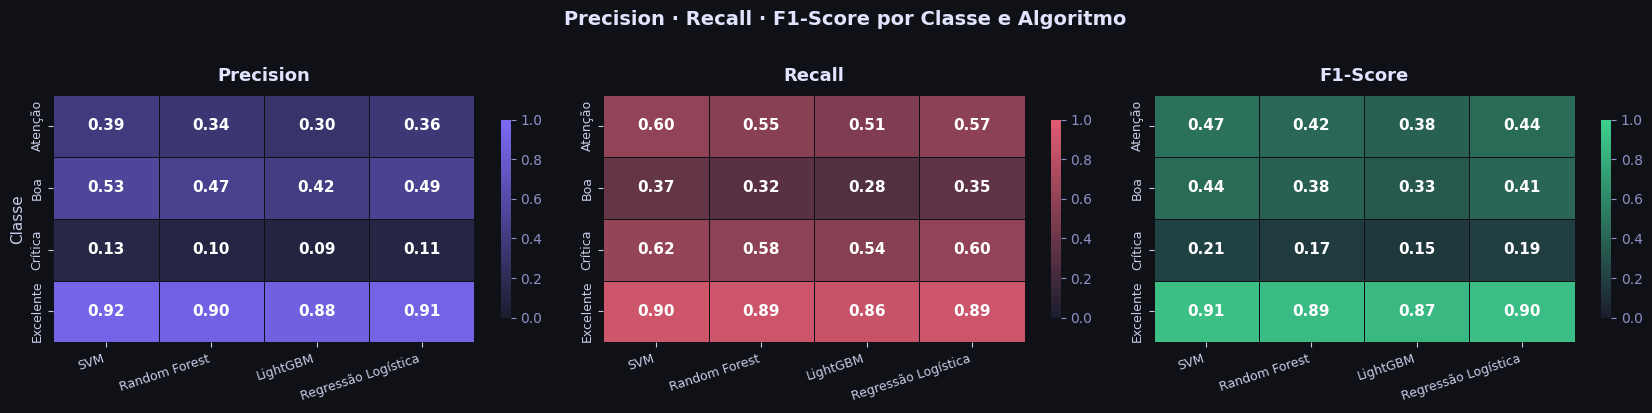

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Precision · Recall · F1-Score por Classe e Algoritmo',
             fontsize=14, color='#e0e4ff', fontweight='bold', y=1.02)

titulos = ['Precision', 'Recall', 'F1-Score']
datasets = [precision, recall, f1]
cmaps = [
    LinearSegmentedColormap.from_list('prec', ['#1a1d2e', '#7c6af7']),
    LinearSegmentedColormap.from_list('rec',  ['#1a1d2e', '#e25c72']),
    LinearSegmentedColormap.from_list('f1',   ['#1a1d2e', '#3ecf8e']),
]

for ax, titulo, df_metric, cmap in zip(axes, titulos, datasets, cmaps):
    mat = df_metric.set_index('Algoritmo')[CLASSES].T
    sns.heatmap(
        mat, ax=ax, cmap=cmap, annot=True, fmt='.2f',
        linewidths=0.5, linecolor='#0f1117',
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 11, 'weight': 'bold', 'color': 'white'},
        vmin=0, vmax=1
    )
    ax.set_title(titulo, fontsize=13, color='#e0e4ff', fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Classe' if ax == axes[0] else '')
    ax.tick_params(colors='#c8cde8', labelsize=9)
    plt.setp(ax.get_xticklabels(), rotation=18, ha='right')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig4_heatmaps_metricas.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 6. Matrizes de Confusão — Os Quatro Algoritmos

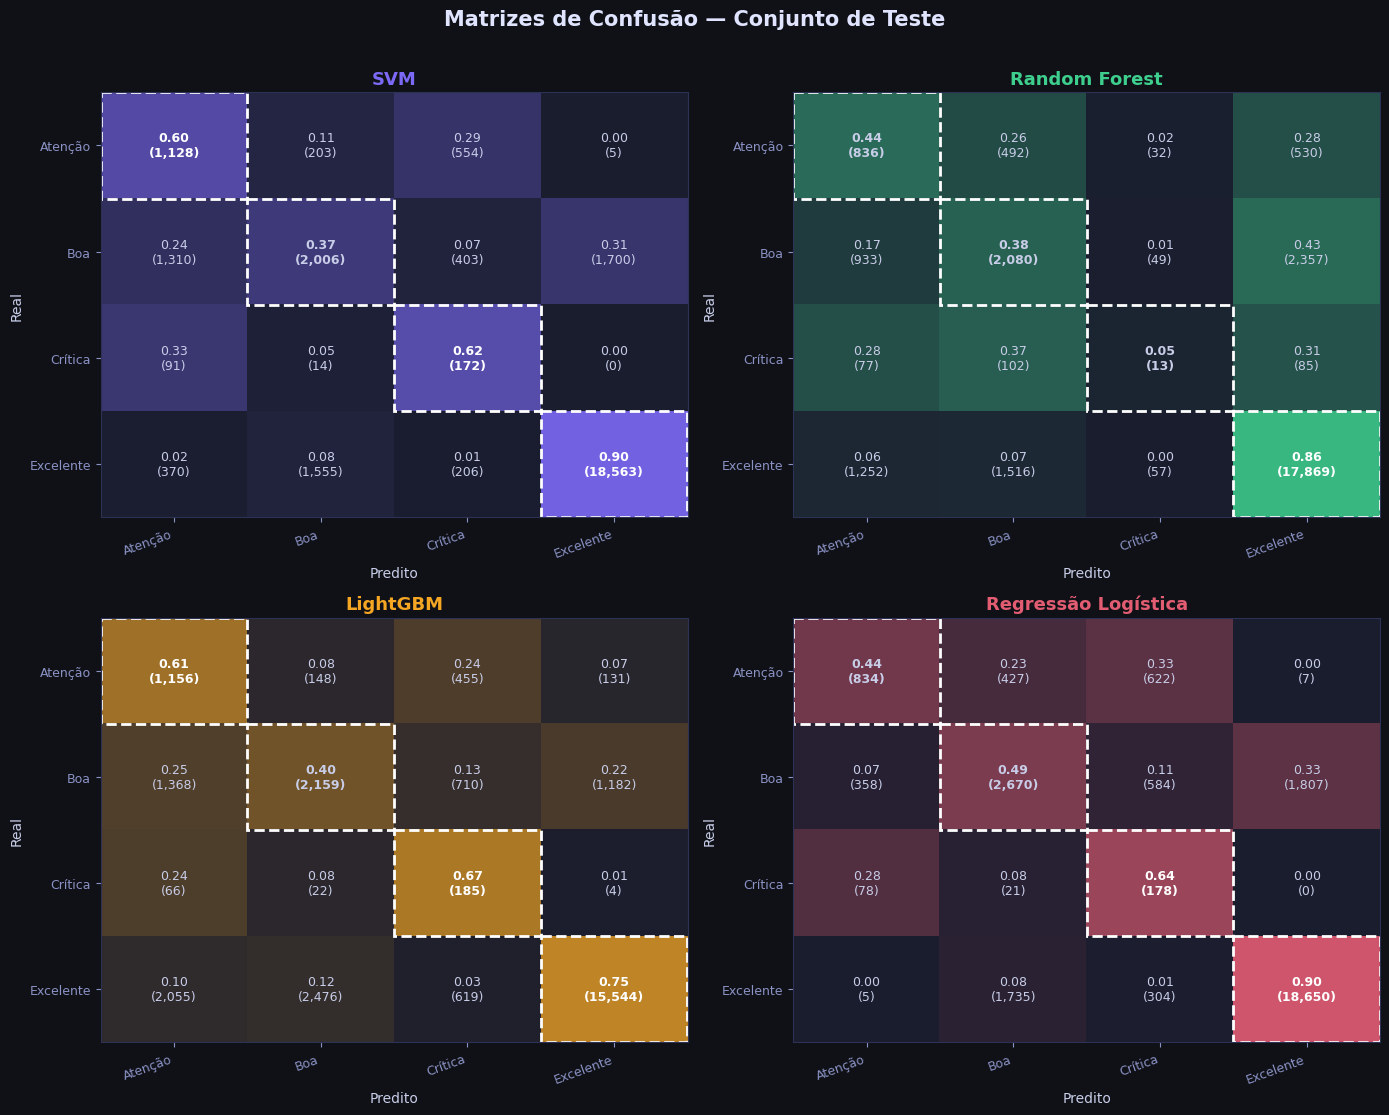

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Matrizes de Confusão — Conjunto de Teste',
             fontsize=15, color='#e0e4ff', fontweight='bold', y=1.01)

cms = [cm_svm, cm_rf, cm_lgbm, cm_lr]
titulos_cm = ['SVM', 'Random Forest', 'LightGBM', 'Regressão Logística']
cores_cm = ['#7c6af7', '#3ecf8e', '#f5a623', '#e25c72']

for ax, cm, titulo, cor in zip(axes.flat, cms, titulos_cm, cores_cm):
    # Normalizar por linha (recall)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    cmap = LinearSegmentedColormap.from_list(titulo, ['#1a1d2e', cor])
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    for i in range(4):
        for j in range(4):
            branco = cm_norm[i, j] > 0.5
            ax.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]:,})',
                    ha='center', va='center', fontsize=9,
                    color='white' if branco else '#c8cde8',
                    fontweight='bold' if i == j else 'normal')

    ax.set_title(titulo, color=cor, fontsize=13, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(CLASSES, fontsize=9)
    ax.set_xlabel('Predito', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

    # Destacar diagonal
    for k in range(4):
        rect = plt.Rectangle((k-0.5, k-0.5), 1, 1,
                              fill=False, edgecolor='white',
                              linewidth=2, linestyle='--')
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig5_matrizes_confusao.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 7. Radar Chart — Perfil Global de Cada Algoritmo

Visualização multidimensional que compara os algoritmos em seis eixos simultâneos.

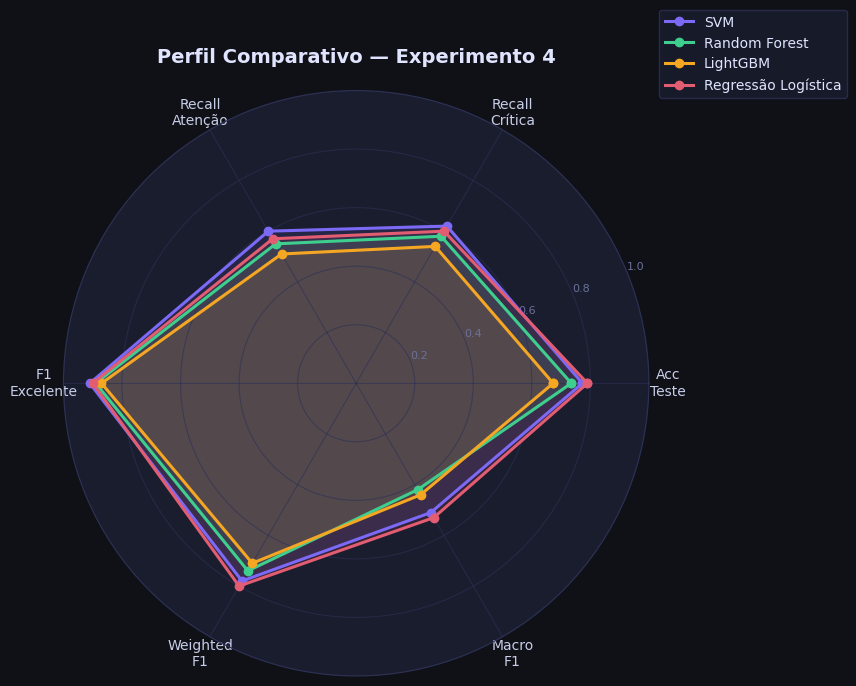

In [10]:
from matplotlib.patches import FancyArrowPatch

categorias = [
    'Acc\nTeste',
    'Recall\nCrítica',
    'Recall\nAtenção',
    'F1\nExcelente',
    'Weighted\nF1',
    'Macro\nF1',
]

dados_radar = {
    'SVM':                 [0.773, 0.62, 0.60, 0.91, 0.78, 0.51],
    'Random Forest':       [0.735, 0.58, 0.55, 0.89, 0.74, 0.42],
    'LightGBM':            [0.673, 0.54, 0.51, 0.87, 0.71, 0.44],
    'Regressão Logística': [0.790, 0.60, 0.57, 0.90, 0.80, 0.53],
}

N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # fechar o polígono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

# Grid
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='#6b7199', fontsize=8)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, color='#c8cde8', fontsize=10)
ax.grid(color='#2d3154', linewidth=0.8)
ax.spines['polar'].set_color('#2d3154')

for algo, vals in dados_radar.items():
    vals_plot = vals + vals[:1]
    cor = CORES[algo]
    ax.plot(angulos, vals_plot, 'o-', linewidth=2.2, color=cor, label=algo)
    ax.fill(angulos, vals_plot, alpha=0.12, color=cor)

ax.set_title('Perfil Comparativo — Experimento 4',
             fontsize=14, color='#e0e4ff', fontweight='bold', pad=20)

ax.legend(
    loc='upper right', bbox_to_anchor=(1.35, 1.15),
    facecolor='#1a1d2e', edgecolor='#2d3154',
    labelcolor='#e0e4ff', fontsize=10
)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig6_radar_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 8. Resumo Final — Rankings

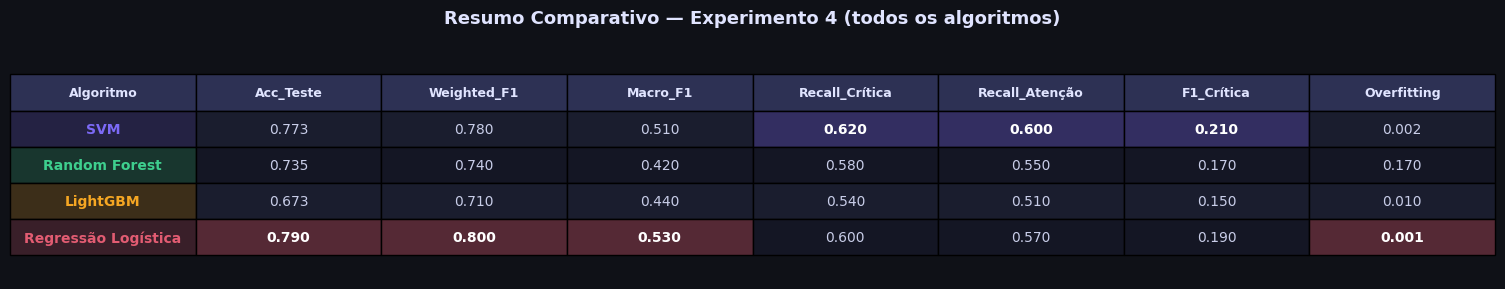

In [11]:
resumo = pd.DataFrame({
    'Algoritmo':           algos,
    'Acc_Teste':           [0.773, 0.735, 0.673, 0.790],
    'Weighted_F1':         [0.78,  0.74,  0.71,  0.80],
    'Macro_F1':            [0.51,  0.42,  0.44,  0.53],
    'Recall_Crítica':      [0.62,  0.58,  0.54,  0.60],
    'Recall_Atenção':      [0.60,  0.55,  0.51,  0.57],
    'F1_Crítica':          [0.21,  0.17,  0.15,  0.19],
    'Overfitting':         [0.002, 0.170, 0.010, 0.001],
})

# ── Plot da tabela ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 3))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.axis('off')

colunas_tabela = list(resumo.columns)
valores = resumo.values

tabela = ax.table(
    cellText=[[f'{v:.3f}' if isinstance(v, float) else v for v in row] for row in valores],
    colLabels=colunas_tabela,
    loc='center',
    cellLoc='center',
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 2.2)

# Estilizar cabeçalho
for j, _ in enumerate(colunas_tabela):
    tabela[(0, j)].set_facecolor('#2d3154')
    tabela[(0, j)].set_text_props(color='#e0e4ff', fontweight='bold', fontsize=9)

# Estilizar linhas de dados
destaques = {
    'Acc_Teste': 3,       # RL tem maior
    'Weighted_F1': 3,
    'Macro_F1': 3,
    'Recall_Crítica': 0,  # SVM tem maior
    'Recall_Atenção': 0,
    'F1_Crítica': 0,
    'Overfitting': 3,     # RL tem menor (melhor)
}

for i, (_, row) in enumerate(resumo.iterrows()):
    algo = row['Algoritmo']
    cor_algo = CORES[algo]
    for j, col in enumerate(colunas_tabela):
        cell = tabela[(i+1, j)]
        cell.set_facecolor('#1a1d2e' if i % 2 == 0 else '#141624')
        cell.set_text_props(color='#c8cde8')
        if col == 'Algoritmo':
            cell.set_facecolor(cor_algo + '33')
            cell.set_text_props(color=cor_algo, fontweight='bold')
        # Destacar melhores valores
        if col in destaques and destaques[col] == i:
            cell.set_facecolor(cor_algo + '55')
            cell.set_text_props(color='white', fontweight='bold')

ax.set_title('Resumo Comparativo — Experimento 4 (todos os algoritmos)',
             fontsize=13, color='#e0e4ff', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig7_tabela_resumo.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 9. Análise do Trade-off: Recall Crítica × Acurácia Global

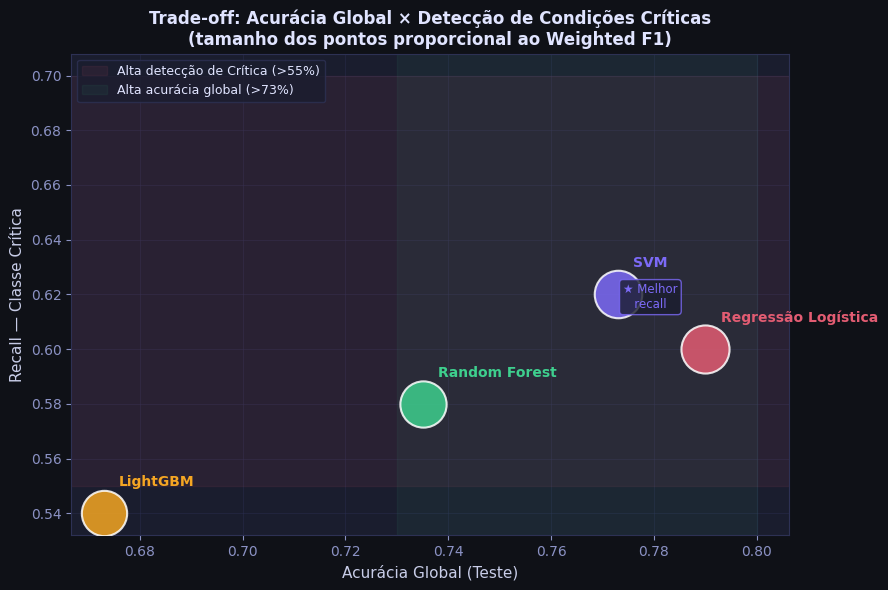

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f1117')

x_vals = [0.773, 0.735, 0.673, 0.790]   # Acc_Teste
y_vals = [0.62,  0.58,  0.54,  0.60]    # Recall_Crítica
tamanhos = [v * 1500 for v in [0.78, 0.74, 0.71, 0.80]]  # Weighted F1

for i, (algo, x, y, s) in enumerate(zip(algos, x_vals, y_vals, tamanhos)):
    cor = CORES[algo]
    ax.scatter(x, y, s=s, color=cor, alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(algo,
                xy=(x, y),
                xytext=(x + 0.003, y + 0.01),
                fontsize=10, color=cor, fontweight='bold')

# Zona de interesse
ax.axhspan(0.55, 0.70, alpha=0.08, color='#e25c72', label='Alta detecção de Crítica (>55%)')
ax.axvspan(0.73, 0.80, alpha=0.06, color='#3ecf8e', label='Alta acurácia global (>73%)')

ax.set_xlabel('Acurácia Global (Teste)', fontsize=11)
ax.set_ylabel('Recall — Classe Crítica', fontsize=11)
ax.set_title('Trade-off: Acurácia Global × Detecção de Condições Críticas\n'
             '(tamanho dos pontos proporcional ao Weighted F1)',
             fontsize=12, color='#e0e4ff', fontweight='bold')
ax.legend(facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e4ff', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Quadrante ideal (alto-alto)
ax.text(0.774, 0.615, '★ Melhor\n   recall', color='#7c6af7', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1d2e', edgecolor='#7c6af7', alpha=0.8))

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig8_tradeoff_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 10. Conclusões

### Ranking geral — Experimento 4

| # | Algoritmo | Pontos Fortes | Pontos Fracos |
|---|---|---|---|
| 🥇 | **SVM** | Melhor recall em `Crítica` (0.62) e `Atenção` (0.60); melhor F1 para `Crítica` (0.21); maior macro F1 (0.51) | Acurácia global mediana (0.773) |
| 🥈 | **Regressão Logística** | Maior acurácia geral (0.790) e maior weighted F1 (0.80); overfitting mínimo (0.001) | Recall de `Crítica` ligeiramente inferior ao SVM |
| 🥉 | **Random Forest** | Boa acurácia de treino; recall de `Excelente` elevado | Overfitting severo (0.170); pior recall de `Crítica` entre os modelos lineares |
| 4º | **LightGBM** | Overfitting muito baixo (0.010); maior recall de `Crítica` no contexto de pouquíssimas variáveis | Menor acurácia geral (0.673); weighted F1 mais baixo |

### Leitura ambiental

Para o **monitoramento de qualidade hídrica**, detectar condições críticas é mais importante do que maximizar a acurácia geral:

- O **SVM** é o modelo mais indicado para implantação: oferece o maior recall nas classes de risco (`Crítica` e `Atenção`) com generalização sólida (overfitting de 0.002).
- A **Regressão Logística** é uma alternativa competitiva quando a acurácia global também é relevante, com overfitting praticamente nulo.
- O **LightGBM** apresentou excelente capacidade de generalização, evidenciada pelo baixo overfitting. Entretanto, o desempenho inferior nas métricas de teste sugere subajuste do modelo diante do conjunto reduzido de variáveis. Já o **Random Forest** apresentou elevada capacidade de aprendizado no conjunto de treino, porém o grande aumento entre as métricas de treino e teste indica overfitting severo, comprometendo sua capacidade de generalização